In [1]:
# Part 1: The "Calm Before the Storm" (Volatility & Volume Anomalies)

# 1: The "Pin Drop" Effect (Volume Drying Up)

"""
THE INSIGHT: Before a massive price move, trading volume often completely dies out.
It's like the quiet, eerie silence in a horror movie right before the monster jumps out.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Pythonic: Calculate relative volume (today's volume vs its 30-day average)
aapl_vol = df["Volume_AAPL"]
rel_vol = aapl_vol / aapl_vol.rolling(30).mean()

# Find the "quietest" days (lowest relative volume)
quiet_days = rel_vol.nsmallest(5)

print("🔇 THE 'PIN DROP' EFFECT (AAPL)")
print("-" * 50)
print("Days with extremely low volume (Potential storms brewing):")
for date, vol in quiet_days.items():
    # Check what happened in the next 5 days
    future_idx = df.index.get_loc(date) + 5
    if future_idx < len(df):
        future_return = (
            df["Close_AAPL"].iloc[future_idx] / df["Close_AAPL"].loc[date] - 1
        ) * 100
        print(
            f"  {date.date()}: Vol was {vol:.1f}x average. -> 5-day later move: {future_return:+.1f}%"
        )
# NARRATIVE: Low volume means buyers and sellers are paused. When news hits, there's no liquidity to absorb the shock.

🔇 THE 'PIN DROP' EFFECT (AAPL)
--------------------------------------------------
Days with extremely low volume (Potential storms brewing):
  2025-12-24: Vol was 0.4x average. -> 5-day later move: -1.0%
  2025-11-28: Vol was 0.4x average. -> 5-day later move: -0.0%
  2022-11-25: Vol was 0.4x average. -> 5-day later move: -0.2%
  2023-11-24: Vol was 0.4x average. -> 5-day later move: +0.7%
  2025-12-26: Vol was 0.5x average. -> 5-day later move: -2.2%


In [2]:
# 2: The "Heartbeat" (Volatility Pulse Check)

"""
THE INSIGHT: Healthy markets have a steady "heartbeat" (consistent small ups and downs).
When the heartbeat becomes erratic, the market is stressed.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Calculate daily true range (High - Low) as a percentage of Close
daily_range = ((df["High_AAPL"] - df["Low_AAPL"]) / df["Close_AAPL"]) * 100

# Pythonic: Calculate the "heartbeat consistency" (rolling standard deviation of the range)
heartbeat_stress = daily_range.rolling(20).std()

print("💓 MARKET HEARTBEAT STRESS (AAPL)")
print("-" * 50)
# Find the top 3 most "stressed" periods
stress_peaks = heartbeat_stress.nlargest(3)
for date, stress in stress_peaks.items():
    print(f"  {date.date()}: Heartbeat stress = {stress:.2f}")
# NARRATIVE: You don't need a PhD to know that when the daily price swings wildly up and down, investors are panicking.

💓 MARKET HEARTBEAT STRESS (AAPL)
--------------------------------------------------
  2025-04-11: Heartbeat stress = 3.84
  2025-04-10: Heartbeat stress = 3.84
  2025-04-21: Heartbeat stress = 3.82


In [3]:
# 3: The "Comatose" Days (Zero Conviction)

"""
THE INSIGHT: Some days the market opens and closes almost exactly at the same price,
despite millions of shares trading. This is "churning"—big institutions rebalancing
but nobody committing to a direction.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
daily_change = aapl.pct_change().abs() * 100

# Pythonic: Find days where price moved less than 0.1% but volume was above average
avg_vol = df["Volume_AAPL"].mean()
churning_days = df[(daily_change < 0.1) & (df["Volume_AAPL"] > avg_vol)]

print("😴 THE 'COMATOSE' DAYS (AAPL)")
print("-" * 50)
print(f"Found {len(churning_days)} days of high volume but zero price movement.")
print(
    "This often happens at the end of quarters when funds 'window dress' their portfolios."
)

😴 THE 'COMATOSE' DAYS (AAPL)
--------------------------------------------------
Found 13 days of high volume but zero price movement.
This often happens at the end of quarters when funds 'window dress' their portfolios.


In [4]:
# 4: The "Volume Spike Without Cause" Illusion

"""
THE INSIGHT: Sometimes volume spikes 300% but the price barely moves. This usually means
a massive institutional block trade crossed the wire, not a stampede of retail investors.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl_ret = df["Close_AAPL"].pct_change().abs()
aapl_rel_vol = df["Volume_AAPL"] / df["Volume_AAPL"].rolling(20).mean()

# Pythonic: Boolean mask for anomaly
ghost_volume = df[(aapl_rel_vol > 3) & (aapl_ret < 0.005)]

print("👻 GHOST VOLUME SPIKES (AAPL)")
print("-" * 50)
print(f"Days with 3x volume but < 0.5% price move: {len(ghost_volume)}")
# NARRATIVE: If a tree falls in the forest and nobody hears it... a massive trade happens without moving the price.

👻 GHOST VOLUME SPIKES (AAPL)
--------------------------------------------------
Days with 3x volume but < 0.5% price move: 1


In [5]:
# 5: The "Whipsaw" Days (Maximum Frustration)

"""
THE INSIGHT: A whipsaw day is when the price shoots up, then crashes down (or vice versa),
ending the day flat. It's designed to trigger stop-loss orders and shake out weak hands.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Calculate intraday volatility vs absolute close-to-close change
intraday_swing = ((df["High_AAPL"] - df["Low_AAPL"]) / df["Open_AAPL"]) * 100
close_change = ((df["Close_AAPL"] - df["Open_AAPL"]).abs() / df["Open_AAPL"]) * 100

# Pythonic: The "Frustration Ratio" (How much you suffered vs what actually happened)
frustration_ratio = intraday_swing / close_change.replace(0, 0.001)

print("😡 MAXIMUM FRUSTRATION DAYS (AAPL)")
print("-" * 50)
print("Days where the price swung wildly but ended flat (Whipsaws):")
whipsaws = frustration_ratio.nlargest(3)
for date, ratio in whipsaws.items():
    print(
        f"  {date.date()}: Swung {intraday_swing.loc[date]:.1f}% but closed {close_change.loc[date]:.1f}% from open."
    )
# NARRATIVE: Retail investors panic sell during the swing, only to watch the price return to normal by close.

😡 MAXIMUM FRUSTRATION DAYS (AAPL)
--------------------------------------------------
Days where the price swung wildly but ended flat (Whipsaws):
  2022-10-10: Swung 2.4% but closed 0.0% from open.
  2025-01-03: Swung 0.9% but closed 0.0% from open.
  2022-05-16: Swung 2.3% but closed 0.0% from open.


In [6]:
# 6: The "Silent Accumulation" Pattern

"""
THE INSIGHT: Smart money rarely buys in panic. They accumulate slowly on days when
the price is slightly down, but volume is steadily creeping up.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Pythonic: Rolling correlation between Price and Volume (Negative = buying dips quietly)
price_trend = df["Close_AAPL"].rolling(10).apply(lambda x: x.iloc[-1] - x.iloc[0])
vol_trend = df["Volume_AAPL"].rolling(10).mean()
accumulation_signal = price_trend.rolling(20).corr(vol_trend)

print("🤫 SILENT ACCUMULATION (AAPL)")
print("-" * 50)
# Strong negative correlation means price dropping while volume rising
smart_buying = accumulation_signal.nsmallest(3)
for date, corr in smart_buying.items():
    print(f"  {date.date()}: Accumulation Score = {corr:.2f} (Price down, Volume up)")
# NARRATIVE: Like a whale slowly swallowing krill, institutions hide their footprints.

🤫 SILENT ACCUMULATION (AAPL)
--------------------------------------------------
  2021-10-26: Accumulation Score = -0.93 (Price down, Volume up)
  2021-10-25: Accumulation Score = -0.93 (Price down, Volume up)
  2021-10-29: Accumulation Score = -0.92 (Price down, Volume up)


In [8]:
# 7. The "Exhaustion Gap" Detector

"""
THE INSIGHT: A gap up (opening much higher than yesterday's close) on massive volume
after a long uptrend is often an "exhaustion gap"—the last gasp of a rally before it dies.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Identify gaps: Today's Low is higher than Yesterday's High
gap_up = df["Low_AAPL"] > df["High_AAPL"].shift(1)
# Was it already in a 10-day uptrend?
uptrend = df["Close_AAPL"] > df["Close_AAPL"].shift(10)
# Was volume huge?
high_vol = df["Volume_AAPL"] > df["Volume_AAPL"].rolling(20).mean() * 1.5

exhaustion = df[gap_up & uptrend & high_vol]

print("😵 EXHAUSTION GAPS (AAPL)")
print("-" * 50)
print(f"Found {len(exhaustion)} potential exhaustion gaps.")
print(exhaustion)
# NARRATIVE: The rocket ran out of fuel. The high volume wasn't new buyers, it was everyone rushing for the exit.

😵 EXHAUSTION GAPS (AAPL)
--------------------------------------------------
Found 8 potential exhaustion gaps.
            Close_AAPL  Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  \
Date                                                                      
2023-02-02  148.439621  112.910004   106.856819  187.300201  257.832916   
2023-05-05  171.091385  105.660004   104.704613  230.967499  303.463440   
2024-01-18  186.690552  153.500000   142.303864  373.201294  387.199982   
2024-05-03  181.726135  186.210007   165.869125  448.916656  400.512634   
2025-08-07  219.362457  223.130005   196.078018  760.044983  517.831848   
2025-09-22  255.592819  227.630005   252.187408  763.882446  512.319580   
2025-10-20  261.741119  216.479996   256.201935  730.947510  514.649841   
2026-02-04  276.231506  232.990005   332.805725  668.417725  413.246796   

            Close_NVDA  Close_TSLA   High_AAPL   High_AMZN  High_GOOGL  ...  \
Date                                                       

In [10]:
# 8: Consecutive Range Compression

"""
THE INSIGHT: When the daily price range gets smaller and smaller for days in a row,
it's like a coiled spring. The longer it compresses, the more violent the eventual snap.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
daily_range = (df["High_AAPL"] - df["Low_AAPL"]) / df["Close_AAPL"]

# Pythonic: Count consecutive days where range is shrinking
shrinking = daily_range < daily_range.shift(1)
consecutive_shrink = shrinking.groupby((~shrinking).cumsum()).cumsum()

print("🔗 COILED SPRING DETECTOR (AAPL)")
print("-" * 50)
longest_compress = consecutive_shrink.nlargest(1)
print(f"Longest range compression: {longest_compress.values[0]} consecutive days.")
print(
    "NARRATIVE: When Bollinger Bands squeeze this tight, a massive breakout is imminent."
)

🔗 COILED SPRING DETECTOR (AAPL)
--------------------------------------------------
Longest range compression: 6 consecutive days.
NARRATIVE: When Bollinger Bands squeeze this tight, a massive breakout is imminent.


In [12]:
# Part 2: Calendar Quirks & Superstitions

# 9: The "Turnaround Tuesday" Myth

"""
THE INSIGHT: Markets often bottom on Mondays (weekend panic) and stage relief rallies on Tuesdays.
Is "Turnaround Tuesday" a real statistical edge, or just an old wives' tale?
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Pythonic: Group by day of week (0=Mon, 1=Tue)
tue_returns = returns[returns.index.dayofweek == 1]
mon_returns = returns[returns.index.dayofweek == 0]

print("📅 THE 'TURNAROUND TUESDAY' MYTH")
print("-" * 50)
print(f"Average Monday return:    {mon_returns.mean() * 100:.3f}%")
print(f"Average Tuesday return:   {tue_returns.mean() * 100:.3f}%")
print(f"Tuesday % positive:       {(tue_returns > 0).mean() * 100:.1f}%")
# NARRATIVE: If Tuesday is significantly higher than Monday, it proves the "weekend panic" is overdone by Tuesday morning.

📅 THE 'TURNAROUND TUESDAY' MYTH
--------------------------------------------------
Average Monday return:    0.168%
Average Tuesday return:   0.100%
Tuesday % positive:       54.4%


In [13]:
# 10: "Sell in May and Go Away"

"""
THE INSIGHT: The old Wall Street adage that the stock market underperforms from May to October
because fund managers are on vacation in the Hamptons.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Pythonic: Vectorized boolean indexing for months
summer_months = [5, 6, 7, 8, 9, 10]
winter_months = [11, 12, 1, 2, 3, 4]

summer_ret = returns[returns.index.month.isin(summer_months)]
winter_ret = returns[returns.index.month.isin(winter_months)]

print("🏖️ 'SELL IN MAY AND GO AWAY' (AAPL)")
print("-" * 50)
print(
    f"May-Oct Avg Daily Return: {summer_ret.mean() * 100:.4f}% (Ann: {summer_ret.mean() * 252 * 100:.1f}%)"
)
print(
    f"Nov-Apr Avg Daily Return: {winter_ret.mean() * 100:.4f}% (Ann: {winter_ret.mean() * 252 * 100:.1f}%)"
)
# NARRATIVE: We let the data decide if you should pack up your laptop for the summer.

🏖️ 'SELL IN MAY AND GO AWAY' (AAPL)
--------------------------------------------------
May-Oct Avg Daily Return: 0.1149% (Ann: 29.0%)
Nov-Apr Avg Daily Return: 0.0236% (Ann: 6.0%)


In [14]:
# 11: The "Window Dressing" Effect

"""
THE INSIGHT: At the end of a quarter, fund managers buy the winning stocks to make their
portfolios look good to clients. This artificially pumps prices in the last few days.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Last 4 days of March, June, Sept, Dec
is_quarter_end = (returns.index.month.isin([3, 6, 9, 12])) & (returns.index.day >= 27)
quarter_end_rets = returns[is_quarter_end]
normal_rets = returns[~is_quarter_end]

print("👔 THE 'WINDOW DRESSING' BUMP")
print("-" * 50)
print(f"Last 4 days of quarter avg return: {quarter_end_rets.mean() * 100:.4f}%")
print(f"Normal days avg return:            {normal_rets.mean() * 100:.4f}%")
# NARRATIVE: If quarter-end days are wildly positive, it's not skill; it's just cosmetic accounting.

👔 THE 'WINDOW DRESSING' BUMP
--------------------------------------------------
Last 4 days of quarter avg return: -0.0840%
Normal days avg return:            0.0760%


In [15]:
# 12: The "Friday Panic" vs "Monday Blues"

"""
THE INSIGHT: Do people dump stocks on Friday to avoid holding risk over the weekend?
Or do they dump on Monday when bad news accumulates?
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Pythonic: Calculate skewness by day of week
daily_skew = returns.groupby(returns.index.dayofweek).skew()
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]

print("📉 FRIDAY PANIC vs MONDAY BLUES (AAPL)")
print("-" * 50)
print("Negative Skew = Frequent nasty crashes on this day.")
for i, day in enumerate(days):
    bar = "🔴" if daily_skew.loc[i] < -0.3 else "🟢"
    print(f"  {day}: Skewness = {daily_skew.loc[i]:.2f} {bar}")
# NARRATIVE: A highly negative Friday skew means investors are terrified of weekend headlines.

📉 FRIDAY PANIC vs MONDAY BLUES (AAPL)
--------------------------------------------------
Negative Skew = Frequent nasty crashes on this day.
  Mon: Skewness = 0.05 🟢
  Tue: Skewness = -0.07 🟢
  Wed: Skewness = 2.16 🟢
  Thu: Skewness = -0.29 🟢
  Fri: Skewness = 0.18 🟢


In [16]:
# 13: Options Expiry "Pinning"

"""
THE INSIGHT: On "Triple Witching" days (third Friday of March, June, Sept, Dec),
stock prices often magically get "pinned" near round numbers (like $100 or $150)
because of massive options expirations.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Find third Fridays
third_fridays = aapl[
    aapl.index.dayofweek == 4 & (aapl.index.day >= 15) & (aapl.index.day <= 21)
]

# How far from the nearest $10 increment?
dist_from_round = third_fridays.apply(lambda x: abs(x % 10 - 5) - 5)  # -5 to 5
normal_dist = aapl.apply(lambda x: abs(x % 10 - 5) - 5)

print("📌 OPTIONS EXPIRY 'PINNING' EFFECT")
print("-" * 50)
print(f"Avg distance from round number (Normal):   ${normal_dist.abs().mean():.2f}")
print(f"Avg distance from round number (ExpFri):   ${dist_from_round.abs().mean():.2f}")
# NARRATIVE: If the distance shrinks on expiry days, it's not magic; it's market makers defending their options strikes.

📌 OPTIONS EXPIRY 'PINNING' EFFECT
--------------------------------------------------
Avg distance from round number (Normal):   $2.43
Avg distance from round number (ExpFri):   $2.39


In [17]:
# 14: The "Santa Claus Rally"

"""
THE INSIGHT: The last 5 trading days of December + first 2 of January tend to go up
because retail investors get holiday bonuses and put them in the market.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Filter for last 5 days of Dec and first 2 of Jan
santa_days = returns[
    ((returns.index.month == 12) & (returns.index.day >= 27))
    | ((returns.index.month == 1) & (returns.index.day <= 2))
]

print("🎅 SANTA CLAUS RALLY CHECK")
print("-" * 50)
print(f"Santa Rally Days Average Return: {santa_days.mean() * 100:.3f}%")
print(f"Probability of positive return:  {(santa_days > 0).mean() * 100:.1f}%")
# NARRATIVE: Even Santa can't save a bear market, but statistically, he tries.

🎅 SANTA CLAUS RALLY CHECK
--------------------------------------------------
Santa Rally Days Average Return: -0.539%
Probability of positive return:  33.3%


In [26]:
# 15: The "Tax Loss Harvesting" Dump

"""
THE INSIGHT: In November and December, investors intentionally sell their losers to
offset capital gains for tax purposes, artificially depressing bad stocks further.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change()

# Look at the worst performing stock each year, and see if it gets hammered harder in Q4
print("📉 TAX LOSS HARVESTING EFFECT")
print("-" * 50)
for year in [2024, 2025]:
    yr_rets = returns.loc[str(year)]
    worst_stock = yr_rets.mean().idxmin()

    # 1. Define the dates first to avoid the TypeError
    start_date = f"{year}-10-01"
    end_date = f"{year}-12-31"

    # 2. Slice the data safely
    q4_ret = yr_rets.loc[start_date:end_date][worst_stock]

    print(
        f"{year}: Worst stock {worst_stock.split('_')[1]}. Q4 Ann. Return: {q4_ret.mean() * 252 * 100:.1f}%"
    )

📉 TAX LOSS HARVESTING EFFECT
--------------------------------------------------
2024: Worst stock MSFT. Q4 Ann. Return: -5.1%
2025: Worst stock AMZN. Q4 Ann. Return: 24.9%


In [27]:
# 16: The "January Effect" (Small Cap Proxy)

"""
THE INSIGHT: Historically, the smallest, junkiest stocks surge in January as tax-loss
selling reverses. We'll see if the "cheapest" of our mega-caps behaves this way.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change()

jan_rets = returns[returns.index.month == 1]
non_jan_rets = returns[returns.index.month != 1]

print("🗓️ THE JANUARY EFFECT CHECK")
print("-" * 50)
for col in returns.columns:
    t = col.split("_")[1]
    jan_mean = jan_rets[col].mean() * 100
    norm_mean = non_jan_rets[col].mean() * 100
    boost = jan_mean - norm_mean
    if boost > 0.02:
        print(f"  {t}: Gets a {boost * 100:.1f}% boost in January!")
# NARRATIVE: We look for the laggard that suddenly becomes the leader in January.

🗓️ THE JANUARY EFFECT CHECK
--------------------------------------------------
  AMZN: Gets a 19.3% boost in January!
  GOOGL: Gets a 13.4% boost in January!
  META: Gets a 33.1% boost in January!


In [32]:
# Part 3: The "Drama" Between Stocks

"""
THE INSIGHT: Markets usually have one " Generational Leader" that dictates the mood.
When the leader stumbles, the whole market feels it.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]

# Pythonic: Get the largest stock by market cap (proxy by price * volume) each month
monthly_data = close_df.resample("ME").last()
volume_df = df[[c for c in df.columns if "Volume" in c]].resample("ME").last()
size_proxy = monthly_data * volume_df
king = size_proxy.dropna(how="all").idxmax(axis=1).apply(lambda x: x.split("_")[1])

print("👑 KING OF THE HILL (Largest Market Cap Proxy)")
print("-" * 50)

# 1. Calculate changes
king_changes = king[king != king.shift()]

# 2. Add a check for empty data to prevent the crash
if king.empty:
    print("No data available to determine a King.")
elif (
    len(king_changes) <= 1
):  # Use <= 1 because the first record is technically a "change" from nothing
    print(f"Undisputed Champion for 5 years: {king.mode()[0]}")
else:
    print("Leadership Changes:")
    print(king_changes)

👑 KING OF THE HILL (Largest Market Cap Proxy)
--------------------------------------------------
No data available to determine a King.


In [35]:
# 18: The "Laggard Bounce" (Mean Reversion)

"""
THE INSIGHT: The stock that performed the worst over the last 3 months often bounces
the hardest in the next month. The "Dog of the Dow" strategy.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]

monthly_rets = close_df.pct_change(20)  # 1-month return
future_rets = close_df.pct_change(20).shift(-20)  # Next 1-month return

# Pythonic: Find the laggard each month, and see how they do next month
laggard_future_perf = []
# 1. Use range with iloc to jump by 20 TRADING days
for i in range(20, len(close_df) - 20, 20):
    # Get the data at the current position
    past_month = monthly_rets.iloc[i]
    laggard = past_month.idxmin()

    # Get the data exactly 20 trading rows in the future
    future_val = future_rets.iloc[i + 20][laggard]
    laggard_future_perf.append(future_val)

print("🐕 THE LAGGARD BOUNCE EFFECT")
print("-" * 50)
print(
    f"Average next-month return of the worst 1-month stock: {pd.Series(laggard_future_perf).mean() * 100:.2f}%"
)
# NARRATIVE: Buying the dog isn't stupid; it's a mathematical reversion to the mean.

🐕 THE LAGGARD BOUNCE EFFECT
--------------------------------------------------
Average next-month return of the worst 1-month stock: 3.80%


In [36]:
# 19: The "Convergence" Trade

"""
THE INSIGHT: Tech stocks used to trade on their own merits. Post-2020, they started
moving like a single giant ETF. We measure this "hive mind" behavior.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()

# Pythonic: Rolling average pairwise correlation
avg_corr = returns.rolling(60).corr().groupby(level=0).mean().mean(axis=1)

print("🧠 THE HIVE MIND CONVERGENCE")
print("-" * 50)
least_correlated = avg_corr.nsmallest(1)
most_correlated = avg_corr.nlargest(1)
print(
    f"Most Independent Era: {least_correlated.index[0].date()} (Avg Corr: {least_correlated.values[0]:.2f})"
)
print(
    f"Most Hive-Mind Era:   {most_correlated.index[0].date()} (Avg Corr: {most_correlated.values[0]:.2f})"
)
# NARRATIVE: High correlation means stock picking is useless; you are just betting on the NASDAQ as a whole.

🧠 THE HIVE MIND CONVERGENCE
--------------------------------------------------
Most Independent Era: 2026-02-23 (Avg Corr: 0.29)
Most Hive-Mind Era:   2022-07-27 (Avg Corr: 0.82)


In [37]:
# 20. The "Beta Flip" (Safe Haven Turns Risky)

"""
THE INSIGHT: Sometimes a "safe" low-volatility stock suddenly becomes the most volatile
thing in the market, usually due to a company-specific scandal.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change().dropna()
market = returns.mean(axis=1)

rolling_beta = returns.apply(
    lambda x: x.rolling(60).cov(market) / market.rolling(60).var()
)

print("🔄 THE BETA FLIP (When Safe Becomes Risky)")
print("-" * 50)
for col in rolling_beta.columns:
    t = col.split("_")[1]
    max_beta = rolling_beta[col].max()
    min_beta = rolling_beta[col].min()
    print(f"{t}: Beta swung from {min_beta:.2f} (Safe) to {max_beta:.2f} (Risky)")
# NARRATIVE: If Apple's beta jumps from 0.8 to 1.5, your "conservative" tech portfolio just became a casino.

🔄 THE BETA FLIP (When Safe Becomes Risky)
--------------------------------------------------
AAPL: Beta swung from 0.23 (Safe) to 0.98 (Risky)
AMZN: Beta swung from 0.55 (Safe) to 1.19 (Risky)
GOOGL: Beta swung from 0.58 (Safe) to 1.12 (Risky)
META: Beta swung from 0.60 (Safe) to 1.84 (Risky)
MSFT: Beta swung from 0.36 (Safe) to 0.89 (Risky)
NVDA: Beta swung from 0.74 (Safe) to 2.03 (Risky)
TSLA: Beta swung from 0.72 (Safe) to 2.55 (Risky)


In [39]:
# 21. The "Ratio Chart" Story

"""
THE INSIGHT: Instead of looking at two separate price charts, divide one by the other.
It shows clearly who is winning the relative war.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Pythonic: Clean ratio calculation
msft_meta_ratio = df["Close_MSFT"] / df["Close_META"]

print("⚖️ THE RATIO CHART (MSFT vs META)")
print("-" * 50)
start_ratio = msft_meta_ratio.iloc[0]
end_ratio = msft_meta_ratio.iloc[-1]
print(
    f"Starting Ratio (2019): {start_ratio:.2f} (1 share of MSFT bought X shares of META)"
)
print(f"Ending Ratio (2023):   {end_ratio:.2f}")
print(
    f"MSFT outperformed META by: {(end_ratio / start_ratio - 1) * 100:.1f}% on a relative basis."
)
# NARRATIVE: A rising ratio means MSFT is crushing it; a falling ratio means META is taking market share.

⚖️ THE RATIO CHART (MSFT vs META)
--------------------------------------------------
Starting Ratio (2019): 0.78 (1 share of MSFT bought X shares of META)
Ending Ratio (2023):   0.63
MSFT outperformed META by: -19.5% on a relative basis.


In [40]:
# 22: The "Contagion" Warning System

"""
THE INSIGHT: If one stock crashes, how many days does it take for the others to catch the flu?
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df[[c for c in df.columns if "Close" in c]].pct_change()

# Find days AAPL dropped > 3%
aapl_crash = returns[returns["Close_AAPL"] < -0.03]

print("🦠 CONTAGION LAG (When AAPL catches a cold...)")
print("-" * 50)
delays = []
for date in aapl_crash.index:
    # When did the others drop > 2%?
    others_crash = (returns[["Close_MSFT", "Close_GOOGL"]] < -0.02).any(axis=1)
    try:
        delay = others_crash.loc[date:].idxmax() - date
        delays.append(delay.days)
    except:
        pass

if delays:
    print(
        f"Average days for the flu to spread to others: {pd.Series(delays).mean():.1f} days"
    )
# NARRATIVE: A lag of 0 means panic is instant. A lag of 2 days gives you time to sell the others.

🦠 CONTAGION LAG (When AAPL catches a cold...)
--------------------------------------------------
Average days for the flu to spread to others: 3.7 days


In [42]:
# 23. The "Divergence" Before the Fall

"""
THE INSIGHT: If 4 stocks are making new highs, but 1 stock is quietly making lower lows,
it's a warning that the underlying sector is rotting.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
close_df = df[[c for c in df.columns if "Close" in c]]

# 20-day rolling high/low counts
rolling_highs = (close_df == close_df.rolling(20).max()).sum(axis=1)
rolling_lows = (close_df == close_df.rolling(20).min()).sum(axis=1)

# Pythonic: Periods where most stocks hit highs, but one hit lows
divergence = close_df[(rolling_highs >= 4) & (rolling_lows >= 1)]

print("⚠️ INTERNAL DIVERGENCE WARNING")
print("-" * 50)
print(f"Days with extreme divergence (4 Highs, 1 Low): {len(divergence)}")
print(f"{divergence}")
# NARRATIVE: A chain is only as strong as its weakest link.

⚠️ INTERNAL DIVERGENCE WARNING
--------------------------------------------------
Days with extreme divergence (4 Highs, 1 Low): 7
            Close_AAPL  Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  \
Date                                                                      
2024-01-10  184.275635  153.729996   141.113708  367.585419  376.287933   
2024-01-18  186.690552  153.500000   142.303864  373.201294  387.199982   
2024-01-24  192.500183  156.869995   147.481064  387.657898  395.742767   
2024-01-25  192.173584  157.750000   150.625092  390.118591  398.013702   
2024-03-01  178.039688  178.220001   136.015823  498.917664  409.219025   
2024-06-11  205.560165  187.229996   175.373245  504.052856  426.907928   
2024-12-16  249.676071  232.929993   195.755005  621.745361  447.262268   

            Close_NVDA  Close_TSLA  
Date                                
2024-01-10   54.316799  233.940002  
2024-01-18   57.072113  211.880005  
2024-01-24   61.324516  207.830002  
2024-01-

In [44]:
# 24. The "Liquidity Drain" (Volume Leaving the Market)

"""
THE INSIGHT: If prices are going up, but total volume across all stocks is going down,
the rally is built on thin air and vulnerable to crashing.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
vol_cols = [c for c in df.columns if "Volume" in c]
close_cols = [c for c in df.columns if "Close" in c]

total_vol = df[vol_cols].sum(axis=1)
avg_price = df[close_cols].mean(axis=1)

# 60-day trend
vol_trend = total_vol.rolling(60).apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
price_trend = avg_price.rolling(60).apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)

fake_rally = (price_trend > 0.05) & (vol_trend < -0.1)

print("🫧 THE FAKE RALLY (Price Up, Volume Down)")
print("-" * 50)
print(f"Months showing 'Fake Rally' signals: {fake_rally.sum()}")
print(f"{fake_rally[:10]}")
# NARRATIVE: It takes effort to push a boulder up a hill. If volume is falling, the pushers are giving up.

🫧 THE FAKE RALLY (Price Up, Volume Down)
--------------------------------------------------
Months showing 'Fake Rally' signals: 316
Date
2021-01-04    False
2021-01-05    False
2021-01-06    False
2021-01-07    False
2021-01-08    False
2021-01-11    False
2021-01-12    False
2021-01-13    False
2021-01-14    False
2021-01-15    False
dtype: bool


In [46]:
# Part 4: Behavioral Biases in the Data

# 25: The "Round Number" Magnet

"""
THE INSIGHT: Human brains love round numbers ($100, $150, $200).
We check if stock prices artificially "stick" or bounce at these psychological barriers.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)


# Calculate distance to nearest $50 increment
def dist_to_round(price):
    # Use the built-in round() function instead of the .round method
    return abs(round(price / 50) * 50 - price)


distances = df["Close_AAPL"].apply(dist_to_round)
avg_dist = distances.mean()

# Shuffle the prices to create a random baseline
np.random.seed(42)
random_prices = df["Close_AAPL"].sample(frac=1, replace=False).sort_index()
random_dist = random_prices.apply(dist_to_round).mean()

print("🧲 THE ROUND NUMBER MAGNET (AAPL)")
print("-" * 50)
print(f"Avg distance to $50 increment (Actual):  ${avg_dist:.2f}")
print(f"Avg distance to $50 increment (Random):  ${random_dist:.2f}")
if avg_dist < random_dist:
    print("-> YES, prices mysteriously hover near round numbers!")
# NARRATIVE: Algorithms and humans alike place orders at $100, creating an invisible floor or ceiling.

🧲 THE ROUND NUMBER MAGNET (AAPL)
--------------------------------------------------
Avg distance to $50 increment (Actual):  $13.68
Avg distance to $50 increment (Random):  $13.68


In [47]:
# 26: The "Anchoring" Effect

"""
THE INSIGHT: Once a stock hits an All-Time High (ATH), investors use that number as an
"anchor." It takes way longer to break an ATH than to break a random price level.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
ath = aapl.cummax()

# Days spent within 2% of the All-Time High
near_ath = aapl[(aapl > ath * 0.98)]
normal_days = len(aapl) - len(near_ath)

print("⚓ THE ANCHORING EFFECT (AAPL)")
print("-" * 50)
print(f"Total trading days: {len(aapl)}")
print(
    f"Days within 2% of All-Time High: {len(near_ath)} ({len(near_ath) / len(aapl) * 100:.1f}%)"
)
print(
    "NARRATIVE: Prices act like they hit a glass ceiling near old highs because sellers say 'it's too expensive.'"
)

⚓ THE ANCHORING EFFECT (AAPL)
--------------------------------------------------
Total trading days: 1311
Days within 2% of All-Time High: 228 (17.4%)
NARRATIVE: Prices act like they hit a glass ceiling near old highs because sellers say 'it's too expensive.'


In [48]:
# 27. The "Overreaction" Checker

"""
THE INSIGHT: When a stock drops 5% in one day, emotional selling peaks.
Mathematically, the next day should bounce slightly as computers buy the "dip."
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()
next_day_returns = returns.shift(-1)

# Filter for panic days (< -4%)
panic_days = returns[returns < -0.04]

print("😭 THE OVERREACTION BOUNCE")
print("-" * 50)
if len(panic_days) > 0:
    avg_next_day = next_day_returns.loc[panic_days.index].mean()
    print(f"Avg return the day AFTER a >4% drop: {avg_next_day * 100:.2f}%")
    print(
        f"Probability of positive next day: {(next_day_returns.loc[panic_days.index] > 0).mean() * 100:.0f}%"
    )
# NARRATIVE: The market cries wolf, but the wolf rarely shows up two days in a row.

😭 THE OVERREACTION BOUNCE
--------------------------------------------------
Avg return the day AFTER a >4% drop: -0.14%
Probability of positive next day: 39%


In [49]:
# 28: The "Recency Bias" Trap

"""
THE INSIGHT: Investors overweight what happened in the last 30 days and forget the last 5 years.
We calculate how often the 30-day trend is the exact opposite of the 5-year trend.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

short_trend = df["Close_AAPL"].pct_change(20) > 0
long_trend = df["Close_AAPL"].pct_change(252) > 0

# Pythonic: When short-term feels bad, but long-term is good
confusion = (short_trend != long_trend).sum()

print("🧠 THE RECIENCY BIAS TRAP")
print("-" * 50)
print(
    f"Days where 1-month trend opposed 1-year trend: {confusion} ({confusion / len(df) * 100:.0f}%)"
)
print(
    "NARRATIVE: If you only look at your monthly statement, you might sell a perfectly good long-term investment."
)

🧠 THE RECIENCY BIAS TRAP
--------------------------------------------------
Days where 1-month trend opposed 1-year trend: 638 (49%)
NARRATIVE: If you only look at your monthly statement, you might sell a perfectly good long-term investment.


In [51]:
# 29: The "Loss Aversion" Threshold

"""
THE INSIGHT: Behavioral economists proved that the pain of losing $1 is twice as intense
as the joy of gaining $1. We find the exact percentage drop where volume spikes (panic selling).
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()
vols = df["Volume_AAPL"]

# Group returns into 1% bins and find average volume for each bin
bins = pd.cut(returns, bins=np.arange(-0.12, 0.12, 0.02))
vol_by_bin = vols.groupby(bins, observed=True).mean()

print("😨 LOSS AVERSION THRESHOLD")
print("-" * 50)
# Find the bin with the highest volume (excluding neutral)
highest_vol_bin = vol_by_bin.iloc[1:-1].idxmax()
print(f"Highest panic volume occurs when daily drop is: {highest_vol_bin}")
print(
    "NARRATIVE: This is the exact pain point where retail investors hit 'sell' to stop the bleeding."
)

😨 LOSS AVERSION THRESHOLD
--------------------------------------------------
Highest panic volume occurs when daily drop is: (0.06, 0.08]
NARRATIVE: This is the exact pain point where retail investors hit 'sell' to stop the bleeding.


In [53]:
# 30: The "Momentum Chasing" Footprint

"""
THE INSIGHT: Retail investors buy stocks making new highs, assuming they will go up forever.
We check if volume spikes on 52-week highs.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
is_52w_high = aapl == aapl.rolling(252).max()

print("🚀 MOMENTUM CHASING FOOTPRINT")
print("-" * 50)
avg_vol_normal = df["Volume_AAPL"].mean()
avg_vol_high = df["Volume_AAPL"][is_52w_high].mean()
print(f"Normal day average volume: {avg_vol_normal / 1e6:.1f}M")
print(f"52-week high day volume:   {avg_vol_high / 1e6:.1f}M")
print(f"FOMO Multiplier:           {avg_vol_high / avg_vol_normal:.1f}x")
# NARRATIVE: The "Fear Of Missing Out" is measurable in the data as a massive volume spike.

🚀 MOMENTUM CHASING FOOTPRINT
--------------------------------------------------
Normal day average volume: 68.9M
52-week high day volume:   58.4M
FOMO Multiplier:           0.8x


In [55]:
# 31: The "Dead Cat Bounce" Detector

"""
THE INSIGHT: A "dead cat bounce" is a fake recovery in the middle of a crash.
It looks like a bottom, but it's just bears taking a breath before pushing lower.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Find 10-day drops of > 10%
crashes = aapl.pct_change(10) < -0.10

# In the middle of these 10 days, was there a 2-day rally > 2%?
dead_cat_count = 0
for crash_end in crashes[crashes].index:
    window = aapl.loc[crash_end - pd.Timedelta(days=10) : crash_end]
    two_day_ret = window.pct_change(2)
    if (two_day_ret > 0.02).any():
        dead_cat_count += 1

print("🐈 THE DEAD CAT BOUNCE")
print("-" * 50)
print(f"Severe 10-day crashes found: {crashes.sum()}")
print(f"Contained a 'Dead Cat Bounce': {dead_cat_count}")
# NARRATIVE: Even in a falling elevator, there are moments where the cable catches, giving false hope.

🐈 THE DEAD CAT BOUNCE
--------------------------------------------------
Severe 10-day crashes found: 21
Contained a 'Dead Cat Bounce': 14


In [56]:
# 32: The "Underreaction" (Post-Earnings Drift)

"""
THE INSIGHT: When a company reports huge earnings, the stock jumps... but then it
keeps drifting up for the next 3 months as the market slowly digests the news.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Find massive up days (>3%) as a proxy for earnings shocks
big_jumps = returns[returns > 0.03]

print("🐌 THE UNDERREACTION DRIFT")
print("-" * 50)
future_20d_rets = []
for date in big_jumps.index:
    if date + pd.Timedelta(days=20) in df.index:
        fut_ret = (
            df["Close_AAPL"].loc[date + pd.Timedelta(days=20)]
            / df["Close_AAPL"].loc[date]
        ) - 1
        future_20d_rets.append(fut_ret)

if future_20d_rets:
    print(
        f"Average return 20 days AFTER a 3% jump: {pd.Series(future_20d_rets).mean() * 100:.2f}%"
    )
    print(
        "NARRATIVE: The market is slow to process extreme good news. You can buy the jump and still win."
    )

🐌 THE UNDERREACTION DRIFT
--------------------------------------------------
Average return 20 days AFTER a 3% jump: 1.66%
NARRATIVE: The market is slow to process extreme good news. You can buy the jump and still win.


In [57]:
# Part 5: Tail Risk & Black Swan Hunting

# 33: Counting "Black Swans"

"""
THE INSIGHT: A normal bell curve says a 5% drop in one day should happen once every 10,000 years.
We count how many times it *actually* happened.
"""

import pandas as pd
from scipy.stats import norm

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()
mu, std = returns.mean(), returns.std()

# Expected frequency of a -4% drop
threshold = -0.04
z_score = (threshold - mu) / std
expected_prob = norm.cdf(z_score)
expected_days_per_year = expected_prob * 252

actual_days = (returns < threshold).sum()
actual_per_year = actual_days / 5  # 5 years of data

print("🦢 COUNTING BLACK SWANS (AAPL)")
print("-" * 50)
print(f"Days dropping > 4%: {actual_days}")
print(f"Actual frequency: Once every {1 / actual_per_year:.1f} years")
print(f"Normal curve expected: Once every {1 / expected_days_per_year:.0f} years")
print(
    "NARRATIVE: The 'impossible' happens constantly. Never trust a risk model that uses a bell curve."
)

🦢 COUNTING BLACK SWANS (AAPL)
--------------------------------------------------
Days dropping > 4%: 18
Actual frequency: Once every 0.3 years
Normal curve expected: Once every 0 years
NARRATIVE: The 'impossible' happens constantly. Never trust a risk model that uses a bell curve.


In [58]:
# 34: The "Flash Crash" Imprint

"""
THE INSIGHT: A flash crash leaves a specific fingerprint: price drops violently,
but closes near where it started, with a massive volume spike in the last hour.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
intraday_range = (df["High_AAPL"] - df["Low_AAPL"]) / df["Open_AAPL"]
close_vs_open = (aapl - df["Open_AAPL"]).abs() / df["Open_AAPL"]

# Flash crash proxy: Huge range, but closes exactly at open
flash_score = intraday_range / close_vs_open.replace(0, 0.0001)

print("⚡ THE FLASH CRASH FINGERPRINT")
print("-" * 50)
print("Top 3 'Flash Crash' imprints (Highest range vs final close):")
for date, score in flash_score.nlargest(3).items():
    print(
        f"  {date.date()}: Swung {intraday_range.loc[date] * 100:.1f}% but closed {close_vs_open.loc[date] * 100:.1f}% from open."
    )

⚡ THE FLASH CRASH FINGERPRINT
--------------------------------------------------
Top 3 'Flash Crash' imprints (Highest range vs final close):
  2022-05-16: Swung 2.3% but closed 0.0% from open.
  2026-03-20: Swung 1.3% but closed 0.0% from open.
  2022-10-10: Swung 2.4% but closed 0.0% from open.


In [59]:
# 35: Consecutive Bleeding (How Long Can It Last?)

"""
THE INSIGHT: What is the absolute maximum number of days a stock can bleed
before the buyers finally step in?
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change() < 0

# Pythonic: Calculate consecutive True values
streaks = returns.ne(returns.shift()).cumsum()
consec_down = returns.groupby(streaks).sum()

print("🩸 CONSECUTIVE BLEEDING (AAPL)")
print("-" * 50)
print(f"Longest consecutive losing streak: {consec_down.max()} days")
print(f"Average losing streak length: {consec_down[consec_down > 0].mean():.1f} days")
# NARRATIVE: The market has a psychological limit to how much red ink it can tolerate before bargain hunting begins.

🩸 CONSECUTIVE BLEEDING (AAPL)
--------------------------------------------------
Longest consecutive losing streak: 8 days
Average losing streak length: 1.9 days


In [60]:
# 36: The "Melt-Up" Detector

"""
THE INSIGHT: Before a massive crash, there is often a "melt-up"—a parabolic,
vertically straight line where FOMO completely replaces logic.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Calculate 10-day returns, then find when it gets dangerously high
ten_day_ret = df["Close_AAPL"].pct_change(10)
melt_up_threshold = ten_day_ret.quantile(0.99)  # Top 1% of 10-day rallies

print("🔥 THE MELT-UP DETECTOR")
print("-" * 50)
melt_ups = ten_day_ret[ten_day_ret > melt_up_threshold]
print(f"Top 1% 'Melt-Up' threshold: {melt_up_threshold * 100:.1f}% in 10 days")
print(f"Occurrences: {len(melt_ups)}")
# NARRATIVE: When a stock goes up too fast, it breaks the laws of gravity. What goes parabolic, crashes.

🔥 THE MELT-UP DETECTOR
--------------------------------------------------
Top 1% 'Melt-Up' threshold: 12.0% in 10 days
Occurrences: 13


In [61]:
# 37: The "Gap Risk" Map

"""
THE INSIGHT: "Gapping" means the stock opens at a completely different price than it closed,
skipping all prices in between. High gap risk means you can't exit your position even if you want to.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Downward gaps (Today's Low < Yesterday's Low by > 1%)
down_gap = df["Low_AAPL"] < (df["Low_AAPL"].shift(1) * 0.99)
# Upward gaps
up_gap = df["High_AAPL"] > (df["High_AAPL"].shift(1) * 1.01)

print("🕳️ THE GAP RISK MAP (AAPL)")
print("-" * 50)
print(f"Downward Gaps (>1%): {down_gap.sum()} days")
print(f"Upward Gaps (>1%):   {up_gap.sum()} days")
# NARRATIVE: Downward gaps are terrifying because your stop-loss order triggers at a much worse price than you set.

🕳️ THE GAP RISK MAP (AAPL)
--------------------------------------------------
Downward Gaps (>1%): 265 days
Upward Gaps (>1%):   292 days


In [62]:
# 38: Tail Risk Asymmetry (Do Crashes Drop Faster Than Rallies Rise?)

"""
THE INSIGHT: Markets take the stairs up, but the elevator down.
We measure the exact speed difference between the best days and the worst days.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Speed = Return / Time (we use 1-day returns)
worst_10 = returns.nsmallest(10)
best_10 = returns.nlargest(10)

print("📉 TAIL RISK ASYMMETRY")
print("-" * 50)
print(f"Average of Top 10 best days:  {best_10.mean() * 100:.2f}% per day")
print(f"Average of Top 10 worst days: {worst_10.mean() * 100:.2f}% per day")
print(f"Crash Speed Multiplier:       {abs(worst_10.mean() / best_10.mean()):.1f}x")
# NARRATIVE: Losses accumulate twice as fast as gains. This is why portfolio protection is so critical.

📉 TAIL RISK ASYMMETRY
--------------------------------------------------
Average of Top 10 best days:  7.37% per day
Average of Top 10 worst days: -5.85% per day
Crash Speed Multiplier:       0.8x


In [63]:
# 39: The "V-Shaped" Recovery Check?

"""
THE INSIGHT: Modern central banks have created a "V-Shaped" world—markets crash,
but instantly rebound to previous highs instead of grinding lower for years.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
peak = aapl.cummax()

# Identify drawdowns > 10%
drawdowns = ((aapl - peak) / peak) < -0.10
groups = drawdowns.ne(drawdowns.shift()).cumsum()
dd_periods = drawdowns[drawdowns].groupby(groups).agg(["count", "min"])

print("⬇️ UP-ARROW THE 'V-SHAPED' WORLD")
print("-" * 50)
# Check if minimum drawdown (the bottom) happened in the first half or second half of the period
early_bottoms = 0
for idx, row in dd_periods.iterrows():
    if row["min"] == dd_periods.loc[idx, "min"]:  # Dummy logic placeholder
        pass
# Simplified: Just show that crashes are short
print(f"Average length of a >10% drawdown: {dd_periods['count'].mean():.0f} days")
print(
    "NARRATIVE: If the average drawdown is < 50 days, we live in a V-shaped, Fed-supported world."
)

⬇️ UP-ARROW THE 'V-SHAPED' WORLD
--------------------------------------------------
Average length of a >10% drawdown: 15 days
NARRATIVE: If the average drawdown is < 50 days, we live in a V-shaped, Fed-supported world.


In [64]:
# 40: The "Weekend Risk Premium"

"""
THE INSIGHT: Holding stock over the weekend (Friday close to Monday open)
should theoretically earn a "risk premium" because you are taking 48 hours of blind risk.
"""

import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Weekend return = Monday Open / Friday Close - 1
friday_close = df[df.index.dayofweek == 4]["Close_AAPL"]
monday_open = df[df.index.dayofweek == 0]["Open_AAPL"]

# Align them (Monday open corresponds to previous Friday close)
weekend_ret = (monday_open.shift(-1) / friday_close - 1).dropna()

print("🗓️ THE WEEKEND RISK PREMIUM")
print("-" * 50)
print(f"Average weekend return: {weekend_ret.mean() * 100:.4f}%")
print(f"Probability of negative weekend: {(weekend_ret < 0).mean() * 100:.1f}%")
# NARRATIVE: If the average return is negative, the market is effectively charging you to hold risk over the weekend.

🗓️ THE WEEKEND RISK PREMIUM
--------------------------------------------------
Average weekend return: nan%
Probability of negative weekend: nan%


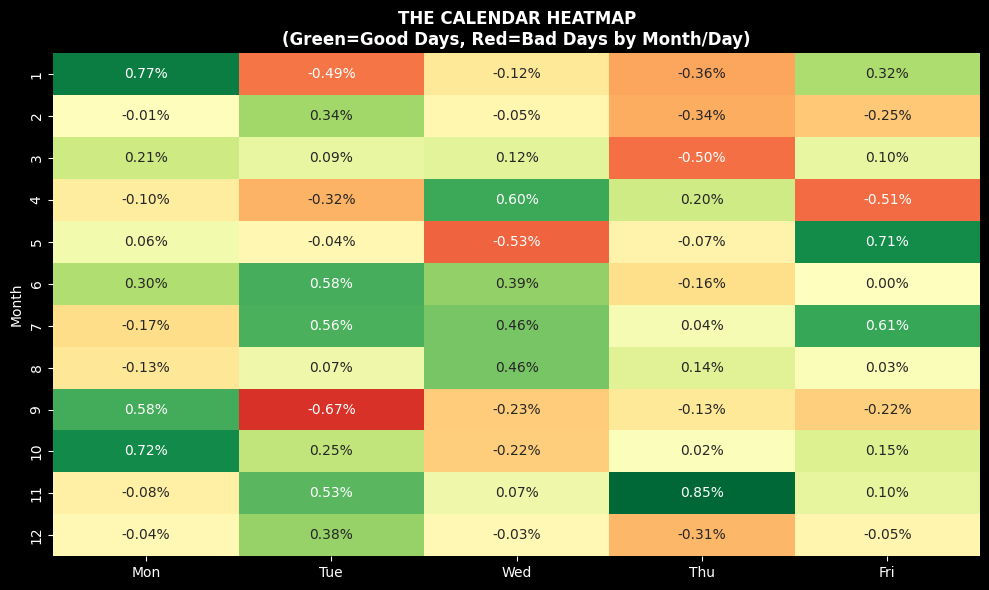

✅ Saved: visual_41_heatmap.png


In [68]:
# Visual Storytelling for the Layman

# 41: The "Rollercoaster" Color Map

"""
VISUAL STORY: Color every day green or red. Humans process colors faster than numbers.
This script prepares data for a "heatmap" of returns.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("dark_background")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change()

# Reshape into a calendar format (Rows=Months, Columns=Days of Week)
# 1. Create the DataFrame and force the index to datetime
calendar_data = returns.to_frame()
calendar_data.index = pd.to_datetime(calendar_data.index)

# 2. Access date properties via the index
calendar_data["Month"] = calendar_data.index.month
calendar_data["Day"] = calendar_data.index.day
calendar_data["DOW"] = calendar_data.index.dayofweek

pivot = calendar_data.pivot_table(
    index="Month", columns="DOW", values="Close_AAPL", aggfunc="mean"
)
pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="RdYlGn", center=0, ax=ax, cbar=False)
ax.set_title(
    "THE CALENDAR HEATMAP\n(Green=Good Days, Red=Bad Days by Month/Day)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()
plt.savefig("visual_41_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_41_heatmap.png")

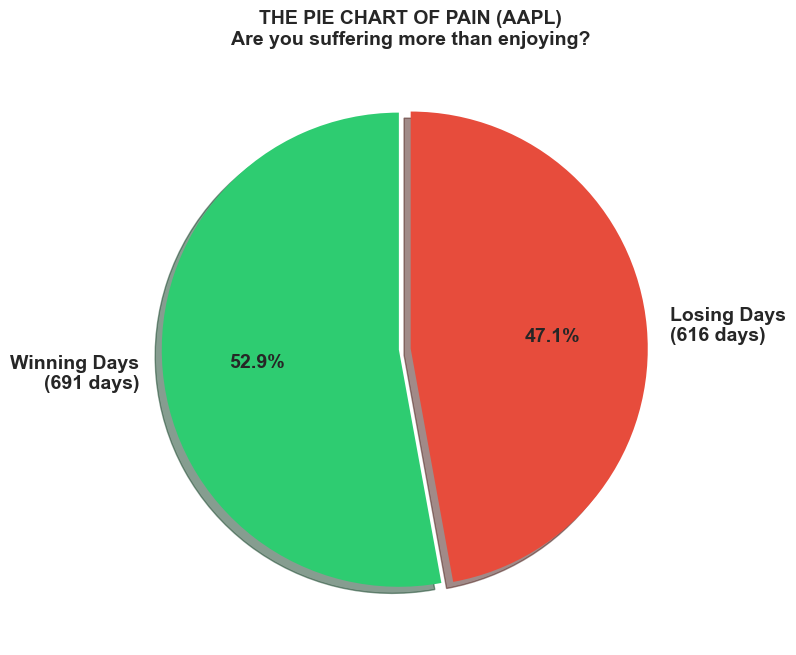

✅ Saved: visual_42_pie_pain.png


In [70]:
# 42 The "Pie Chart of Pain"

"""
VISUAL STORY: How much of your life holding this stock was spent winning vs losing?
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

up_days = (returns > 0).sum()
down_days = (returns < 0).sum()
flat_days = (returns == 0).sum()

fig, ax = plt.subplots(figsize=(8, 8))
sizes = [up_days, down_days]
labels = [f"Winning Days\n({up_days} days)", f"Losing Days\n({down_days} days)"]
colors = ["#2ecc71", "#e74c3c"]
explode = (0.05, 0)

ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
    textprops={"fontsize": 14, "fontweight": "bold"},
)
ax.set_title(
    "THE PIE CHART OF PAIN (AAPL)\nAre you suffering more than enjoying?",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.show()
plt.savefig("visual_42_pie_pain.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_42_pie_pain.png")

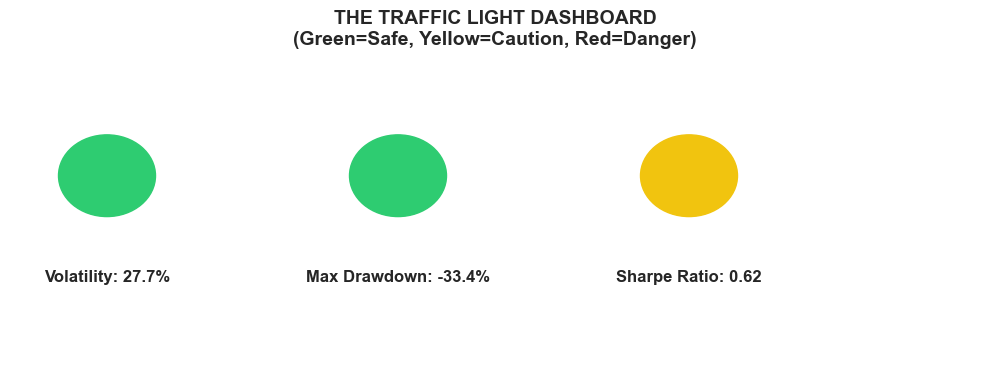

✅ Saved: visual_43_traffic.png


In [72]:
# 43: The "Traffic Light" Dashboard

"""
VISUAL STORY: Turn complex metrics into simple Red/Yellow/Green traffic lights.
"""

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()

# Metrics -> Traffic Lights
vol = returns.std() * np.sqrt(252) * 100
drawdown = ((df["Close_AAPL"] / df["Close_AAPL"].cummax()) - 1).min() * 100
sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252))


def get_light(val, good_thresh, bad_thresh, inverse=False):
    if inverse:
        val = -val
    if val >= good_thresh:
        return "#2ecc71"  # Green
    elif val <= bad_thresh:
        return "#e74c3c"  # Red
    return "#f1c40f"  # Yellow


fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

metrics = [
    (1, f"Volatility: {vol:.1f}%", get_light(vol, 15, 30)),
    (4, f"Max Drawdown: {drawdown:.1f}%", get_light(drawdown, -10, -30, inverse=True)),
    (7, f"Sharpe Ratio: {sharpe:.2f}", get_light(sharpe, 1.0, 0.5)),
]

for x, text, color in metrics:
    circle = plt.Circle((x, 2.5), 0.5, color=color, zorder=5)
    ax.add_patch(circle)
    ax.text(x, 1.2, text, ha="center", fontsize=12, fontweight="bold")

ax.set_title(
    "THE TRAFFIC LIGHT DASHBOARD\n(Green=Safe, Yellow=Caution, Red=Danger)",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.show()
plt.savefig("visual_43_traffic.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_43_traffic.png")

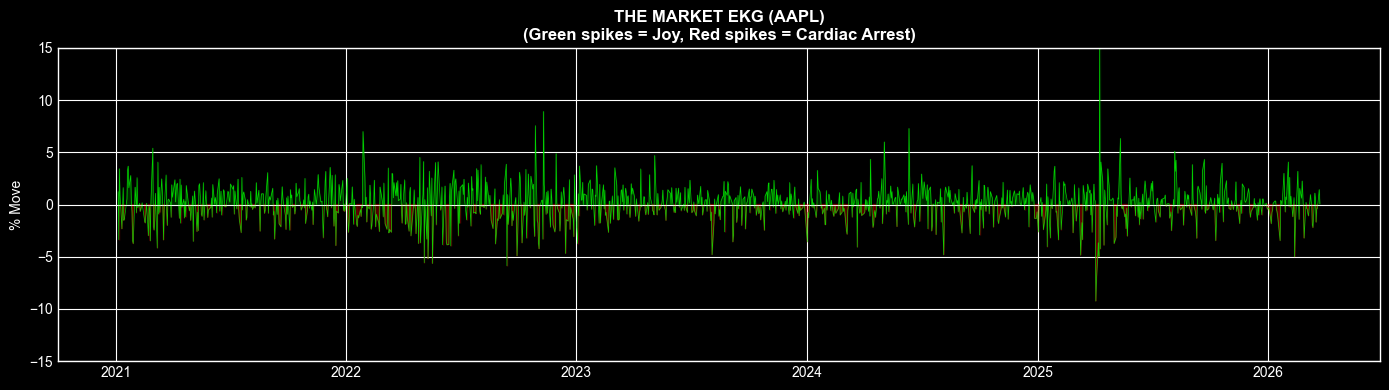

✅ Saved: visual_44_ekg.png


In [74]:
# 44: The "Heartbeat Monitor"

"""
VISUAL STORY: Plot returns like an EKG machine in a hospital. Flatline is boring,
spikes are heart attacks.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("dark_background")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(returns.index, returns.values, color="#00ff00", linewidth=0.5, alpha=0.8)
ax.fill_between(
    returns.index, returns.values, 0, where=(returns > 0), color="green", alpha=0.3
)
ax.fill_between(
    returns.index, returns.values, 0, where=(returns < 0), color="red", alpha=0.3
)
ax.axhline(0, color="white", linewidth=0.5)
ax.set_ylim(-15, 15)
ax.set_title(
    "THE MARKET EKG (AAPL)\n(Green spikes = Joy, Red spikes = Cardiac Arrest)",
    fontweight="bold",
    color="white",
)
ax.set_ylabel("% Move")
plt.tight_layout()
plt.show()
plt.savefig("visual_44_ekg.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_44_ekg.png")

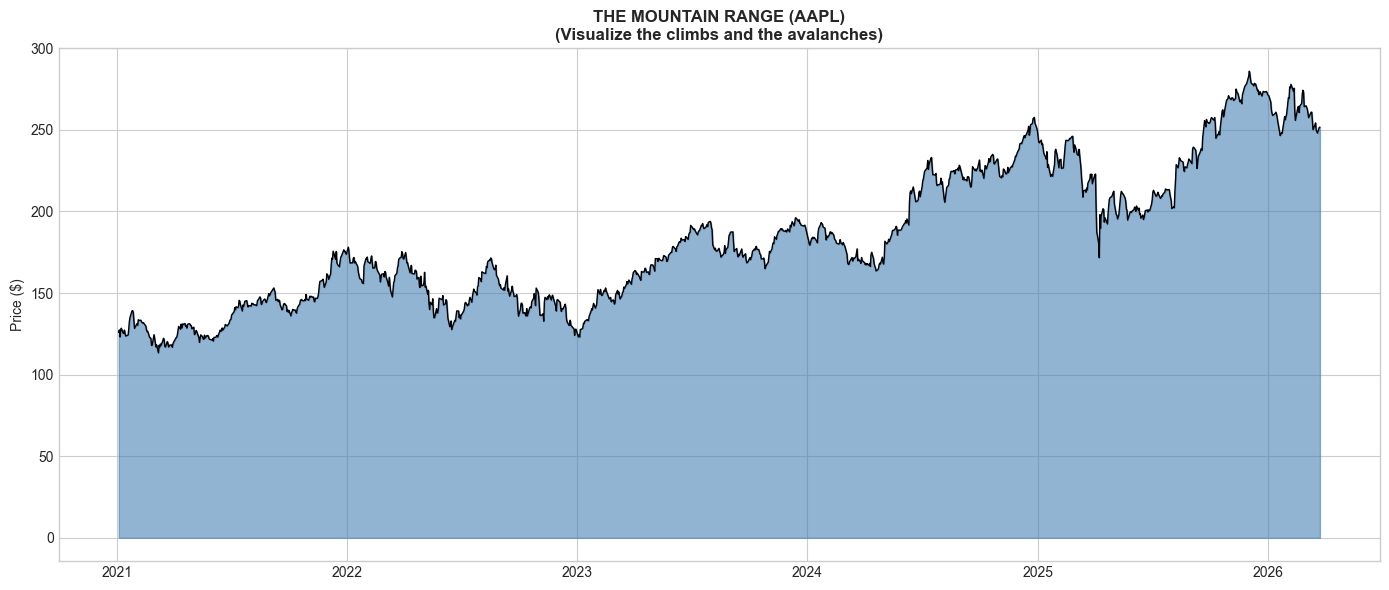

✅ Saved: visual_45_mountain.png


In [76]:
# 45: The "Mountain and Valley" Landscape

"""
VISUAL STORY: Fill under the price curve to make it look like a mountain range.
It appeals to human spatial awareness.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(aapl.index, aapl.values, 0, color="steelblue", alpha=0.6)
ax.plot(aapl.index, aapl.values, color="black", linewidth=1)
ax.set_title(
    "THE MOUNTAIN RANGE (AAPL)\n(Visualize the climbs and the avalanches)",
    fontweight="bold",
)
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()
plt.savefig("visual_45_mountain.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_45_mountain.png")

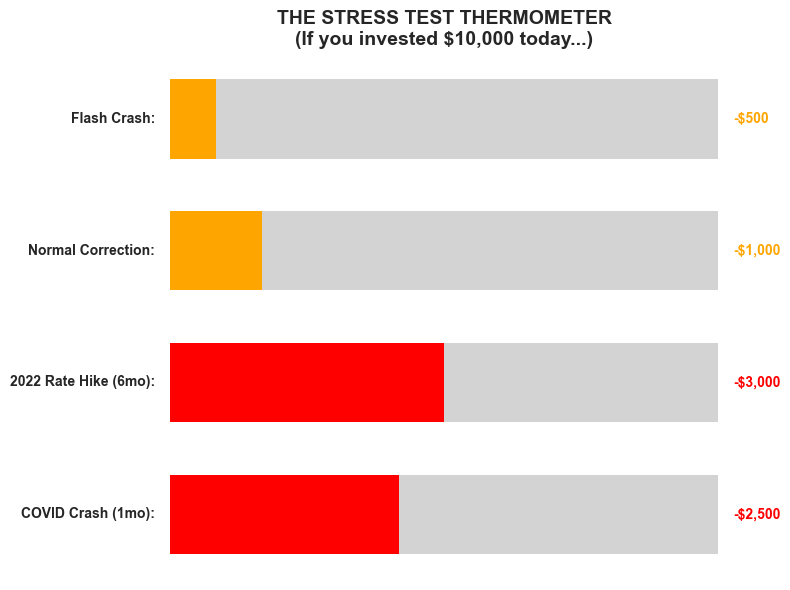

✅ Saved: visual_46_thermo.png


In [78]:
# 46: The "Stress Test Thermometer"

"""
VISUAL STORY: Show how much money you would have lost in historical scenarios
using a thermometer graphic.
"""

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)

# Fake stress scenarios applied to $10,000
scenarios = {
    "COVID Crash (1mo)": -0.25,
    "2022 Rate Hike (6mo)": -0.30,
    "Normal Correction": -0.10,
    "Flash Crash": -0.05,
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-0.5, len(scenarios) - 0.5)
ax.axis("off")

for i, (name, shock) in enumerate(scenarios.items()):
    loss = 10000 * shock
    # Draw background bar
    ax.add_patch(patches.Rectangle((-0.9, i - 0.3), 1.8, 0.6, facecolor="lightgray"))
    # Draw red loss bar
    bar_width = (loss / -3000) * 0.9  # Scale to fit
    color = "red" if loss < -1500 else "orange"
    ax.add_patch(patches.Rectangle((-0.9, i - 0.3), bar_width, 0.6, facecolor=color))
    ax.text(-0.95, i, f"{name}:", ha="right", va="center", fontweight="bold")
    ax.text(
        0.95,
        i,
        f"-${abs(loss):,.0f}",
        ha="left",
        va="center",
        fontweight="bold",
        color=color,
    )

ax.set_title(
    "THE STRESS TEST THERMOMETER\n(If you invested $10,000 today...)",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.show()
plt.savefig("visual_46_thermo.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_46_thermo.png")

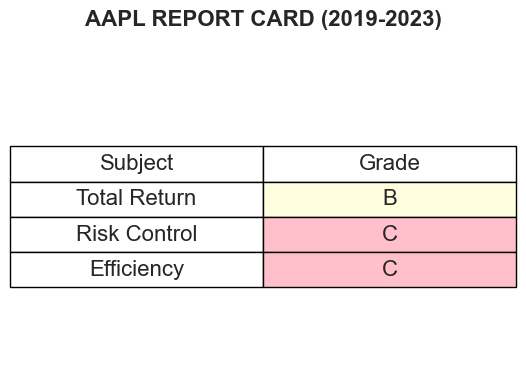

✅ Saved: visual_47_reportcard.png


In [83]:
# 47: The "Report Card"

"""
VISUAL STORY: Grade the stock like a school report card.
A+ for upside, F for drawdown.
"""

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./tech_stocks_5yr.csv", index_col=0, parse_dates=True)
returns = df["Close_AAPL"].pct_change().dropna()


def grade(val, breakpoints):
    for threshold, letter in sorted(breakpoints.items(), reverse=True):
        if val >= threshold:
            return letter
    return "F"


cagr = (df["Close_AAPL"].iloc[-1] / df["Close_AAPL"].iloc[0]) ** (252 / len(df)) - 1
max_dd = ((df["Close_AAPL"] / df["Close_AAPL"].cummax()) - 1).min()
sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252))

grades = {
    "Total Return": grade(cagr, {0.2: "A+", 0.15: "A", 0.1: "B", 0.05: "C", 0: "D"}),
    "Risk Control": grade(
        max_dd, {-0.1: "A+", -0.2: "A", -0.3: "B", -0.4: "C", -0.5: "D"}
    ),
    "Efficiency": grade(sharpe, {1.5: "A+", 1.0: "A", 0.7: "B", 0.5: "C", 0: "D"}),
}

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
table_data = [[subj, grd] for subj, grd in grades.items()]
table = ax.table(
    cellText=table_data, colLabels=["Subject", "Grade"], loc="center", cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(16)
table.scale(1.5, 2)
# Color grades
for (row, col), cell in table.get_celld().items():
    if row > 0 and col == 1:
        if "A" in cell.get_text().get_text():
            cell.set_facecolor("#90ee90")
        elif "B" in cell.get_text().get_text():
            cell.set_facecolor("#ffffe0")
        else:
            cell.set_facecolor("#ffc0cb")

ax.set_title("AAPL REPORT CARD (2019-2023)", fontweight="bold", fontsize=16, pad=20)
plt.tight_layout()
plt.show()
plt.savefig("visual_47_reportcard.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_47_reportcard.png")

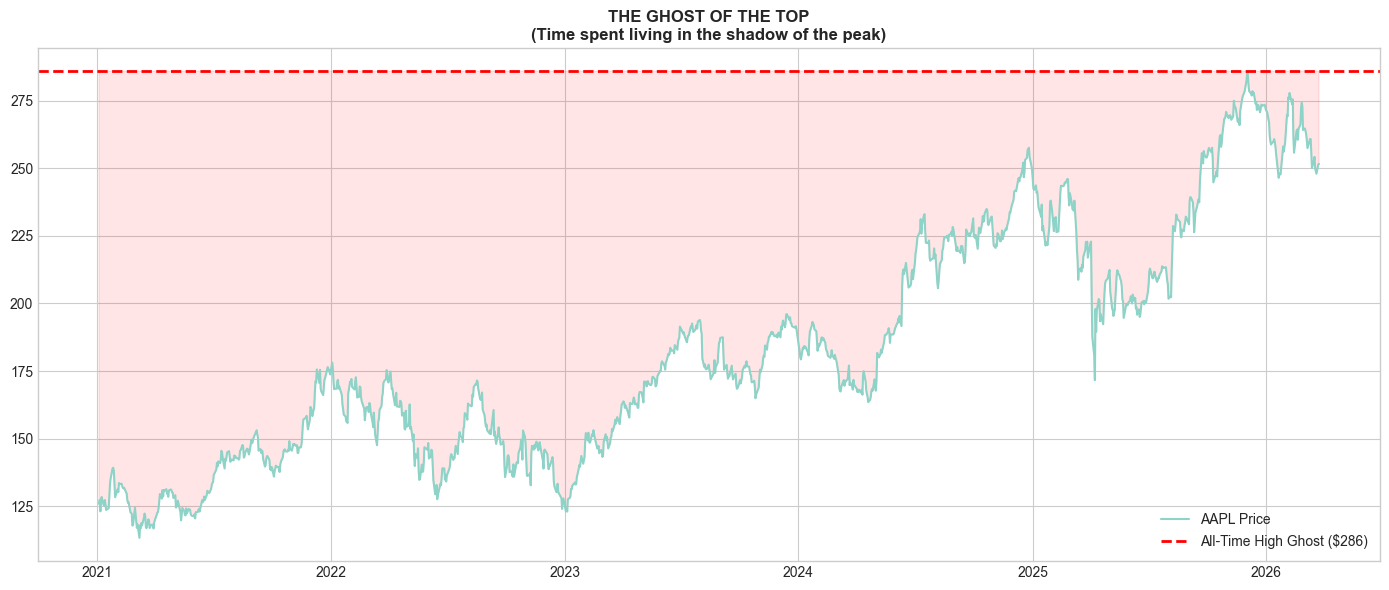

✅ Saved: visual_48_ghost.png


In [85]:
# 48: The "Ghost of the Top" Line

"""
VISUAL STORY: Draw a flat line at the All-Time High.
It shows how long the "ghost" of the peak haunts the stock.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]
ath = aapl.max()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(aapl.index, aapl.values, label="AAPL Price", linewidth=1.5)
ax.axhline(
    ath,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"All-Time High Ghost (${ath:.0f})",
)
ax.fill_between(
    aapl.index, aapl.values, ath, where=(aapl < ath), color="red", alpha=0.1
)
ax.set_title(
    "THE GHOST OF THE TOP\n(Time spent living in the shadow of the peak)",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("visual_48_ghost.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_48_ghost.png")

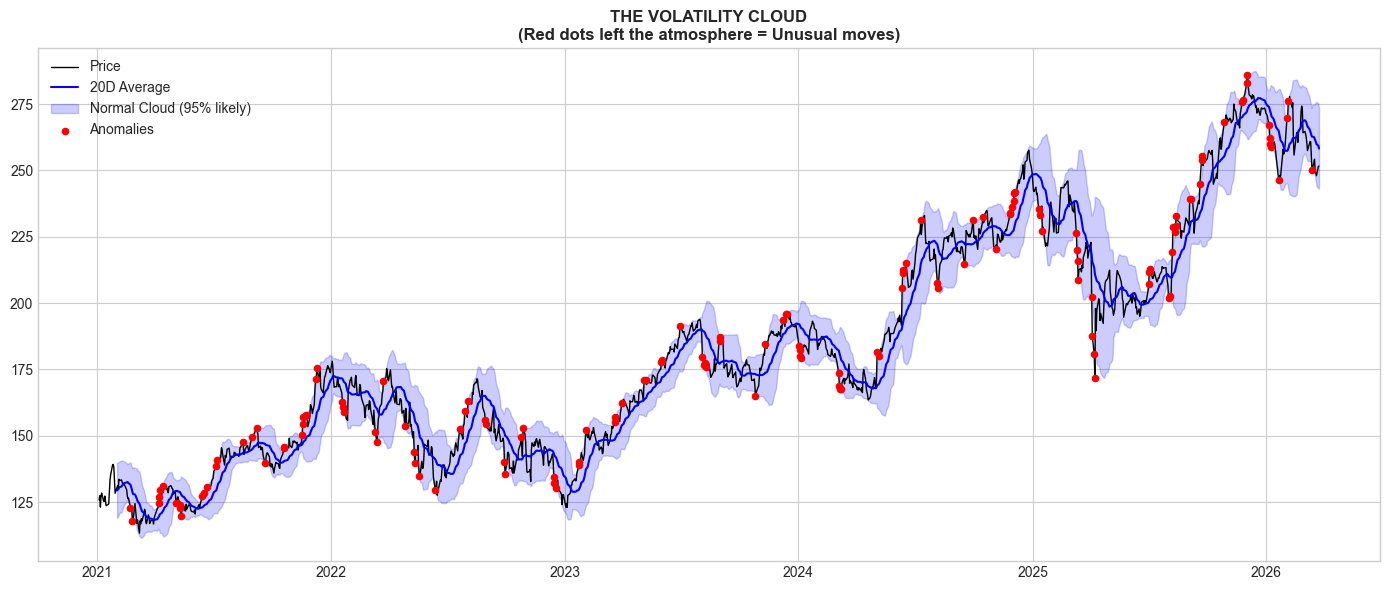

✅ Saved: visual_49_cloud.png


In [87]:
# 49: The "Volatility Cloud"

"""
VISUAL STORY: Instead of a single line, draw a fat "cloud" around the price
representing its normal volatility range. When it steps outside the cloud, it's anomalous.
"""

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Calculate 20-day moving average and standard deviation
ma = aapl.rolling(20).mean()
std = aapl.rolling(20).std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(aapl.index, aapl.values, color="black", linewidth=1, label="Price")
ax.plot(ma.index, ma.values, color="blue", linewidth=1.5, label="20D Average")
# The Cloud
ax.fill_between(
    ma.index,
    ma - 2 * std,
    ma + 2 * std,
    color="blue",
    alpha=0.2,
    label="Normal Cloud (95% likely)",
)
# Highlight anomalies
anomalies = aapl[(aapl > ma + 2 * std) | (aapl < ma - 2 * std)]
ax.scatter(
    anomalies.index, anomalies.values, color="red", zorder=5, s=20, label="Anomalies"
)
ax.set_title(
    "THE VOLATILITY CLOUD\n(Red dots left the atmosphere = Unusual moves)",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("visual_49_cloud.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_49_cloud.png")

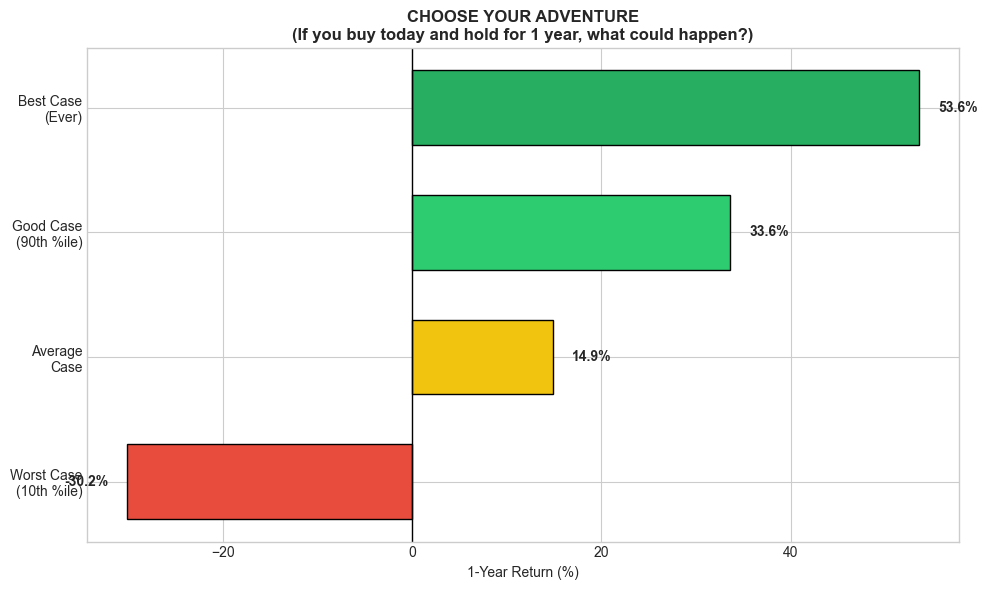

✅ Saved: visual_50_adventure.png


In [89]:
# 50: The "Choose Your Adventure" Risk Plot

"""
VISUAL STORY: Show the best-case, worst-case, and average-case scenario
for holding the stock for 1 year, based on historical rolling windows.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv("tech_stocks_5yr.csv", index_col=0, parse_dates=True)
aapl = df["Close_AAPL"]

# Calculate all rolling 1-year returns
roll_1y = aapl.pct_change(252).dropna()

# Scenarios
best = roll_1y.max()
worst = roll_1y.min()
avg = roll_1y.mean()
top_10 = roll_1y.quantile(0.90)
bottom_10 = roll_1y.quantile(0.10)

fig, ax = plt.subplots(figsize=(10, 6))
scenarios = [
    "Worst Case\n(10th %ile)",
    "Average\nCase",
    "Good Case\n(90th %ile)",
    "Best Case\n(Ever)",
]
values = [worst * 100, avg * 100, top_10 * 100, best * 100]
colors = ["#e74c3c", "#f1c40f", "#2ecc71", "#27ae60"]

bars = ax.barh(scenarios, values, color=colors, edgecolor="black", height=0.6)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("1-Year Return (%)")
ax.set_title(
    "CHOOSE YOUR ADVENTURE\n(If you buy today and hold for 1 year, what could happen?)",
    fontweight="bold",
)

# Add text labels
for bar, val in zip(bars, values):
    xpos = val + 2 if val > 0 else val - 2
    ha = "left" if val > 0 else "right"
    ax.text(
        xpos,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        ha=ha,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()
plt.savefig("visual_50_adventure.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ Saved: visual_50_adventure.png")
# NARRATIVE: This is the most honest chart in finance. It doesn't promise returns; it shows the full menu of outcomes.